<a href="https://colab.research.google.com/github/nandah4/PCVK_04_26/blob/main/Week02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import numpy as np
from skimage import io
import random

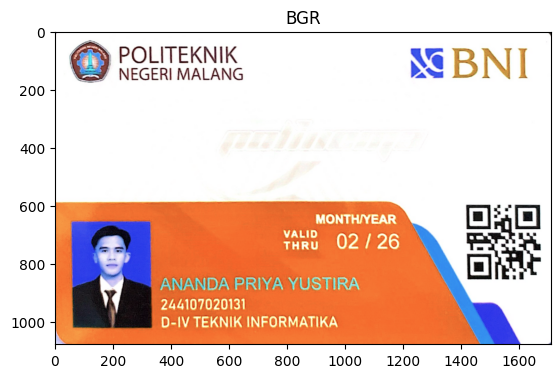

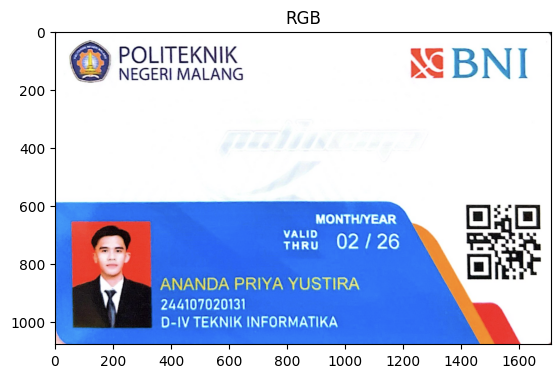

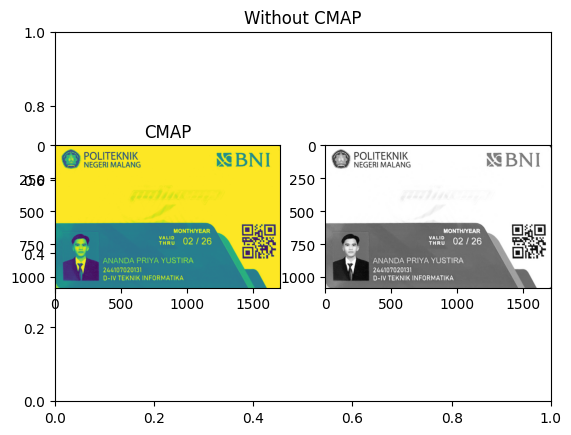

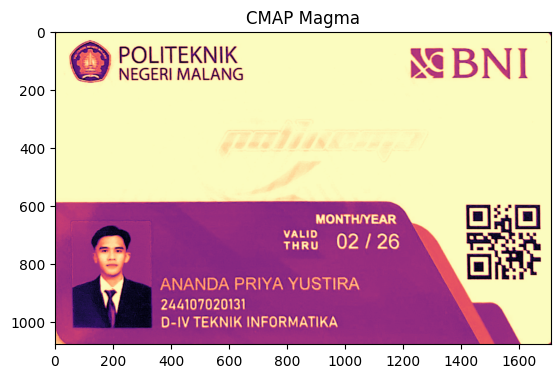

In [6]:


# 2. Menampilkan Gambar

import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

# The way to upload a file using pop up
# from google.colab import files
# uploaded = files.upload()

image = cv2.imread('/content/drive/MyDrive/Polinema/Semester 5/PCVK/Pertemuan 1/KTM_NANDA.png')
# cv2_imshow(image)

# BGR color format
image_BGR = image
plt.title('BGR')
plt.imshow(image_BGR)
plt.show()

# show with RGB format
plt.title('RGB')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

# Grayscale

image_grayscale = cv2.imread('/content/drive/MyDrive/Polinema/Semester 5/PCVK/Pertemuan 1/KTM_NANDA.png', cv2.IMREAD_GRAYSCALE)

plt.title('Without CMAP')
plt.subplot(1, 2, 1)
plt.imshow(image_grayscale)

plt.title('CMAP')
plt.subplot(1, 2, 2)
plt.imshow(image_grayscale, cmap="gray")

plt.show()

plt.title('CMAP Magma')
plt.imshow(image_grayscale, cmap="magma")
plt.show()

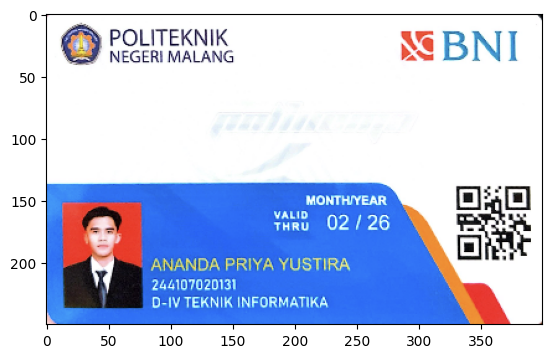

In [12]:
# 4. Resizing
img_RGB = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
img_RGB_small = cv2.resize(img_RGB, (400, 250))
plt.imshow(img_RGB_small)


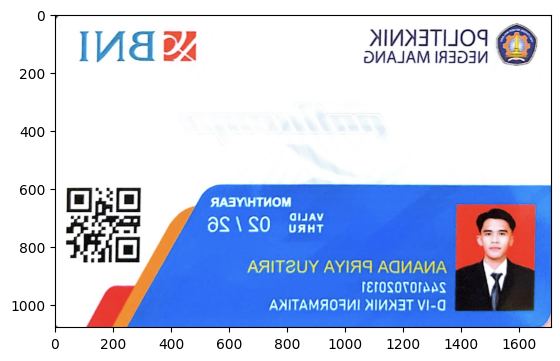

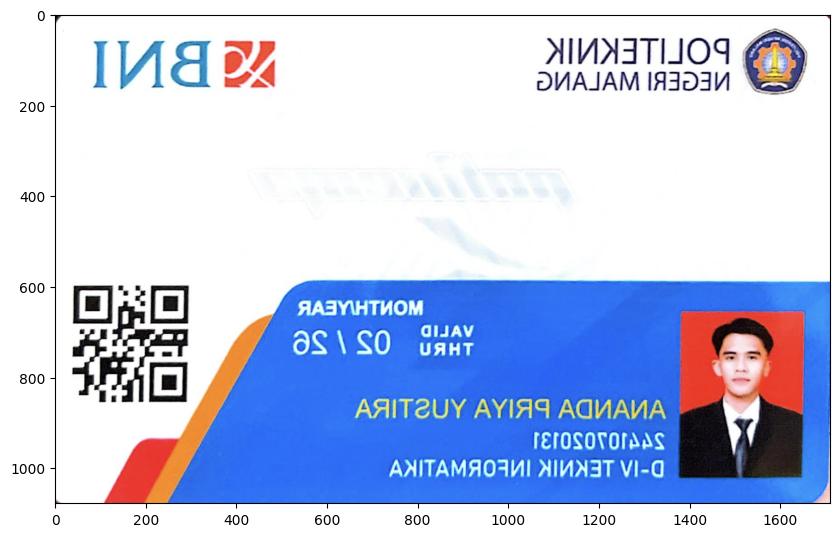

In [8]:
# 5. Flipping
img_flip = cv2.flip(img_RGB, 1)
plt.imshow(img_flip)

# Menampilkan canvas lebih besar
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
ax.imshow(img_flip)

plt.show()

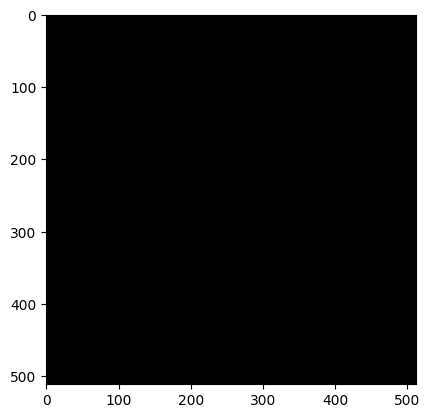

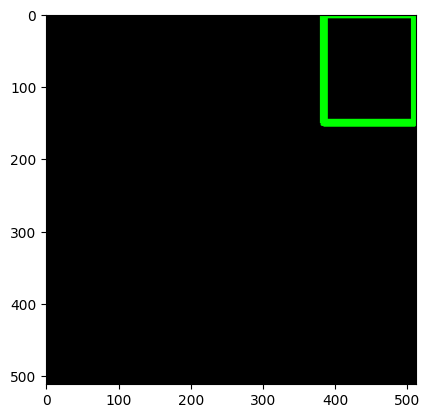

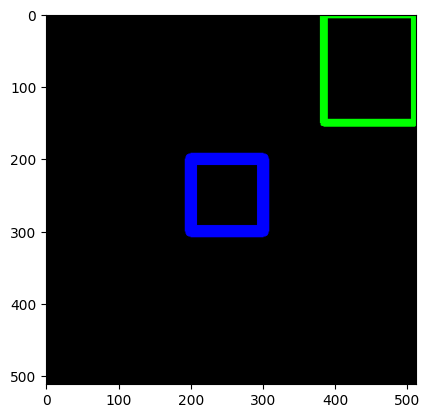

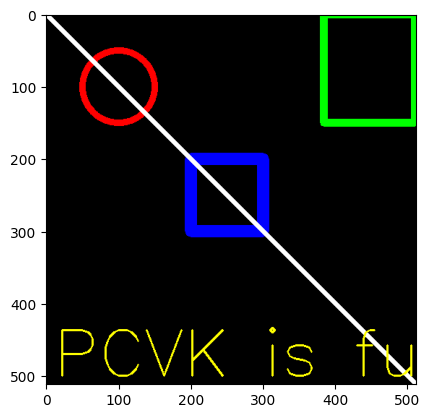

In [13]:
# Membuat bentuk Geometri 2D dari OpenCV. Diawali dengan pembuatan black image dengan tipe data int16.

black_img = np.zeros(shape=(512,512,3), dtype=np.int16)
plt.imshow(black_img)

plt.show()

#Menambahkan bentuk persegi panjang sesuai koordinat pt1 dan pt2
cv2.rectangle(black_img, pt1=(384,0), pt2=(510, 150), color=(0, 255, 0), thickness=10)
plt.imshow (black_img)

plt.show()


cv2.rectangle(black_img, pt1=(200,200), pt2=(300, 300), color=(0, 0, 255), thickness=15)
plt.imshow (black_img)

plt.show()

# Rounded
cv2.circle(black_img, center=(100,100), radius=50, color=(255, 0, 0), thickness=8)

# Line
cv2.line(black_img, pt1=(0,0), pt2=(512, 512), color=(255, 255, 255), thickness=5)

# Font
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(black_img, text="PCVK is fun", org=(10, 500), fontFace=font, fontScale=3, color=(255, 255, 0), thickness=2, lineType=cv2.LINE_AA)
plt.imshow (black_img)

plt.show()

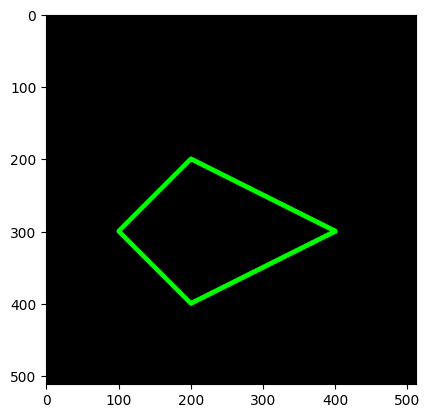

In [14]:
# Black Image 2
black_img_2 = np.zeros(shape=(512,512,3), dtype=np.int32)

vertices = np.array([[100, 300], [200, 200], [400, 300], [200, 400]], dtype=np.int32)

pts = vertices.reshape(
    (-1, 1, 2)
)  # nilai 2 untuk menunjukkan bahwa tiap titik dibuat 3 channel yg mewakili R, G, dan B

cv2.polylines(black_img_2, [pts], isClosed=True, color=(0, 255, 0), thickness=5)
plt.imshow(black_img_2)

plt.show()

# Pertanyaan Praktikum
### 1. Perbedaan cv2_imshow() dan plt.imshow()

Citra yang dibaca menggunakan `cv2.imread()` memiliki urutan warna BGR (Blue, Green, Red).

`cv2_imshow()` dapat menampilkan citra OpenCV dengan format tersebut, sedangkan `plt.imshow()` menganggap citra 3-channel menggunakan urutan RGB (Red, Green, Blue).

Oleh karena itu, jika citra BGR langsung diberikan kepada `plt.imshow()`, kanal Red dan Blue akan tertukar sehingga warna yang ditampilkan berbeda.

Perbedaan tersebut dapat dibuktikan dengan mengambil satu piksel yang sama. Nilai array yang dibaca oleh OpenCV tetap dalam urutan BGR, sedangkan `plt.imshow()` menafsirkan tiga nilai tersebut sebagai RGB. Dengan demikian, nilai array pikselnya sama, tetapi interpretasi kanal warnanya berbeda.

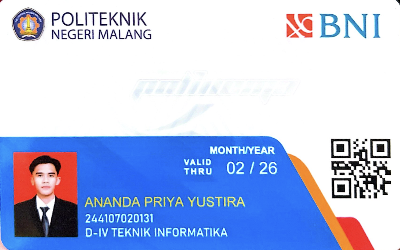

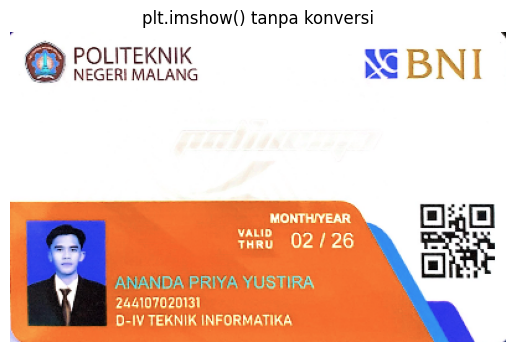

Koordinat pixel: (220, 350)

Jika menggunakan format BGR:
B = 47
G = 55
R = 232

Jika ditafsirkan sebagai RGB oleh plt.imshow():
R = 47
G = 55
B = 232


In [23]:
# Menampilkan dengan cv2_imshow()
resize_img = cv2.resize(image, (400, 250))

cv2_imshow(resize_img)

# Menampilkan dengan plt.imshow() tanpa konversi
plt.imshow(resize_img)
plt.title("plt.imshow() tanpa konversi")
plt.axis('off')
plt.show()

# Ambil satu piksel
y, x = 220, 350

pixel = resize_img[y, x]

print("Koordinat pixel:", (y, x))
print("\nJika menggunakan format BGR:")
print("B =", pixel[0])
print("G =", pixel[1])
print("R =", pixel[2])

print("\nJika ditafsirkan sebagai RGB oleh plt.imshow():")
print("R =", pixel[0])
print("G =", pixel[1])
print("B =", pixel[2])

### 2. Perbandingan int16 dan int32

Dibuat dua kanvas hitam dengan ukuran yang sama, tetapi menggunakan tipe data `int16` dan `int32`.

Keduanya memiliki nilai pixel minimum dan maksimum yang sama karena seluruh pixel diinisialisasi dengan nilai 0. Namun, ukuran memori berbeda karena `int32` menggunakan jumlah bit yang lebih besar dibandingkan `int16`.

Tampilan keduanya tidak berbeda karena keduanya sama-sama berisi nilai 0 yang merepresentasikan warna hitam.

Perbedaan ukuran memori dapat dilihat melalui atribut `nbytes`.

dtype : int16
shape : (500, 500, 3)
min   : 0
max   : 0
nbytes: 1500000
dtype : int32
shape : (500, 500, 3)
min   : 0
max   : 0
nbytes: 3000000

Perbandingan ukuran memori:
int32 / int16 = 2.0


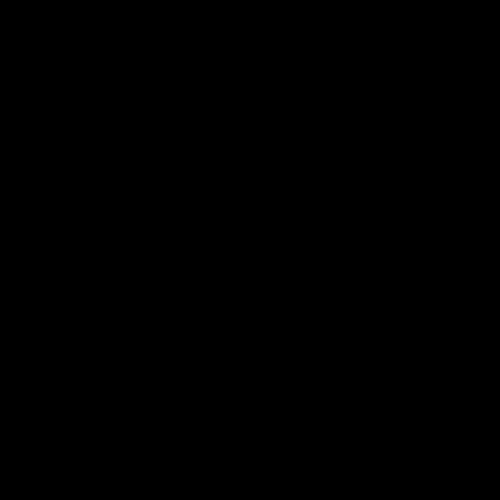

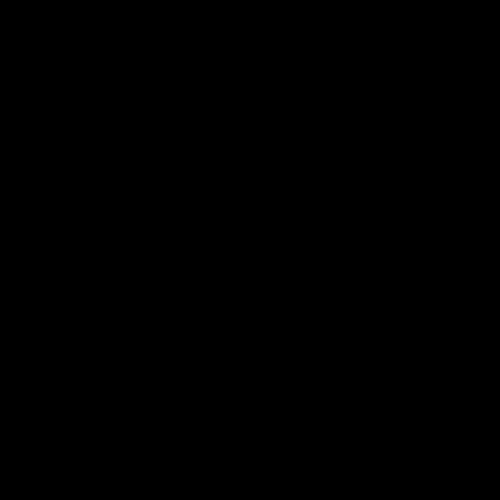

In [24]:
height = 500
width = 500
channels = 3

canvas_int16 = np.zeros((height, width, channels), dtype=np.int16)
canvas_int32 = np.zeros((height, width, channels), dtype=np.int32)

#int16
print("dtype :", canvas_int16.dtype)
print("shape :", canvas_int16.shape)
print("min   :", canvas_int16.min())
print("max   :", canvas_int16.max())
print("nbytes:", canvas_int16.nbytes)

#int32
print("dtype :", canvas_int32.dtype)
print("shape :", canvas_int32.shape)
print("min   :", canvas_int32.min())
print("max   :", canvas_int32.max())
print("nbytes:", canvas_int32.nbytes)

print("\nPerbandingan ukuran memori:")
print("int32 / int16 =", canvas_int32.nbytes / canvas_int16.nbytes)

# Tampilan
cv2_imshow(canvas_int16.astype(np.uint8))
cv2_imshow(canvas_int32.astype(np.uint8))

### 3. Kegunaan cv2_imshow()

Baris: from google.colab.patches import cv2_imshow

digunakan untuk mengimpor fungsi `cv2_imshow()` yang disediakan khusus untuk menampilkan citra OpenCV di Google Colab.

Fungsi `cv2.imshow()` bawaan OpenCV tidak dapat digunakan secara normal di Google Colab karena `cv2.imshow()` membutuhkan window atau GUI desktop untuk menampilkan gambar. Google Colab berjalan pada lingkungan notebook berbasis browser sehingga tidak menyediakan window GUI seperti aplikasi desktop.

Oleh karena itu, Google Colab menyediakan `cv2_imshow()` sebagai alternatif untuk menampilkan citra langsung pada output notebook.

### 4. Perbandingan skimage.io.imread() dan cv2.cvtColor()

Citra yang dibaca menggunakan `skimage.io.imread()` memiliki urutan kanal RGB. Oleh karena itu, jika citra tersebut langsung ditampilkan menggunakan `plt.imshow()`, warnanya ditampilkan dengan benar.

Sebaliknya, `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` hanya benar jika `img` merupakan citra dalam format BGR, seperti citra yang dihasilkan oleh `cv2.imread()`.

Jika hasil `skimage.io.imread()` yang sudah RGB langsung diberikan ke `cv2.cvtColor()` dengan konversi BGR2RGB, maka kanal Red dan Blue justru akan tertukar.

Hal tersebut dibuktikan dengan membandingkan nilai piksel pada koordinat yang sama. Nilai tiga kanal pada hasil konversi akan mengalami pertukaran antara kanal pertama dan ketiga.

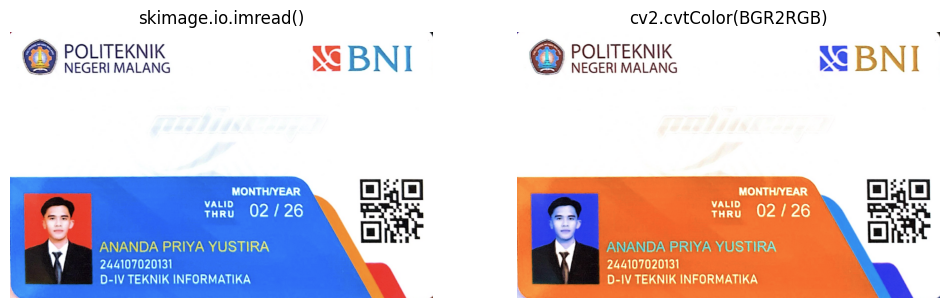

Koordinat: (100, 100)
Pixel skimage (RGB):        [165 187 248 255]
Pixel setelah BGR2RGB:      [248 187 165]


In [26]:
path = '/content/drive/MyDrive/Polinema/Semester 5/PCVK/Pertemuan 1/KTM_NANDA.png'

# Dibaca menggunakan skimage → RGB
img_skimage = io.imread(path)

# Salah jika img_skimage sudah RGB tetapi dianggap BGR
img_swapped = cv2.cvtColor(img_skimage, cv2.COLOR_BGR2RGB)

# Tampilkan berdampingan
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_skimage)
plt.title("skimage.io.imread()")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_swapped)
plt.title("cv2.cvtColor(BGR2RGB)")
plt.axis('off')

plt.show()

# Bukti menggunakan nilai pixel
y, x = 100, 100

print("Koordinat:", (y, x))
print("Pixel skimage (RGB):       ", img_skimage[y, x])
print("Pixel setelah BGR2RGB:     ", img_swapped[y, x])


### 5. Perbedaan ukuran citra dan ukuran tampilan

`figsize` pada Matplotlib hanya mengubah ukuran area atau kanvas tempat citra ditampilkan. Perubahan tersebut tidak mengubah data citra yang tersimpan di dalam variabel `img`.

Ukuran sebenarnya dari citra dapat dilihat menggunakan `img.shape`. Setelah `figsize` diubah, nilai `img.shape` tetap sama.

Dengan demikian, mengubah `figsize` merupakan perubahan ukuran tampilan, sedangkan mengubah ukuran citra merupakan operasi terhadap data pixel, misalnya menggunakan `cv2.resize()`.

shape sebelum ditampilkan: (1078, 1710, 3)


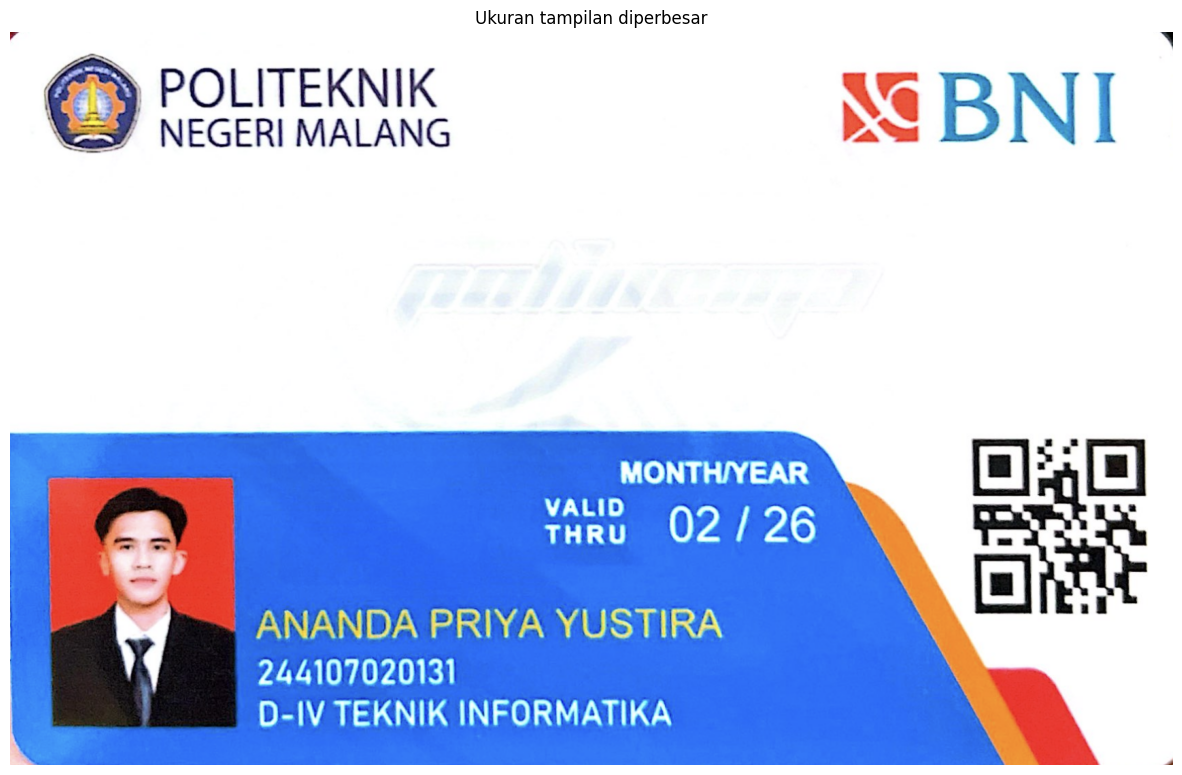

shape setelah figsize diperbesar: (1078, 1710, 3)


In [27]:
img = cv2.imread('/content/drive/MyDrive/Polinema/Semester 5/PCVK/Pertemuan 1/KTM_NANDA.png')

print("shape sebelum ditampilkan:", img.shape)

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Ukuran tampilan diperbesar")
plt.axis('off')
plt.show()

print("shape setelah figsize diperbesar:", img.shape)

# Tugas Praktikum -

### 1. Kombinasi Kanal Warna

Citra ditampilkan menggunakan kombinasi kanal Merah-Biru dan Hijau-Biru. Pada citra Merah-Biru, kanal Hijau dinolkan sehingga hanya informasi kanal Merah dan Biru yang dipertahankan. Pada citra Hijau-Biru, kanal Merah dinolkan sehingga hanya informasi kanal Hijau dan Biru yang dipertahankan.

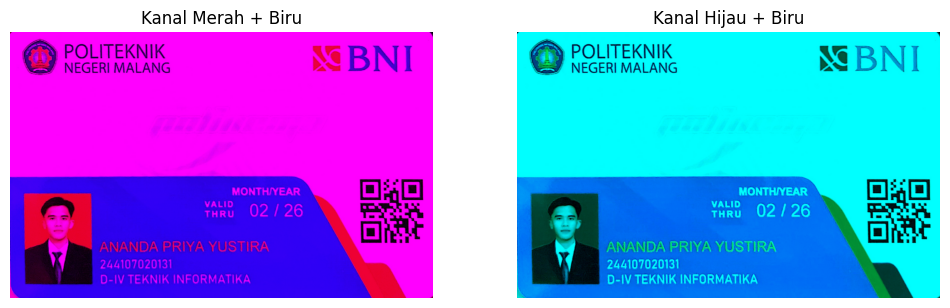

In [31]:
# BGR → RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Merah + Biru
red_blue = image_rgb.copy()

red_blue[:, :, 1] = 0  # Green dinolkan

# Hijau + Biru
green_blue = image_rgb.copy()

green_blue[:, :, 0] = 0  # Red dinolkan

# Tampilkan
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(red_blue)
plt.title("Kanal Merah + Biru")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(green_blue)
plt.title("Kanal Hijau + Biru")
plt.axis("off")

plt.show()

### 2. Pencerminan Citra

Citra dibuat dalam tiga bentuk pencerminan, yaitu pencerminan vertikal, horizontal, dan vertikal sekaligus horizontal. Pencerminan dilakukan menggunakan fungsi `cv2.flip()` dengan parameter 0 untuk vertikal, 1 untuk horizontal, dan -1 untuk kedua arah.

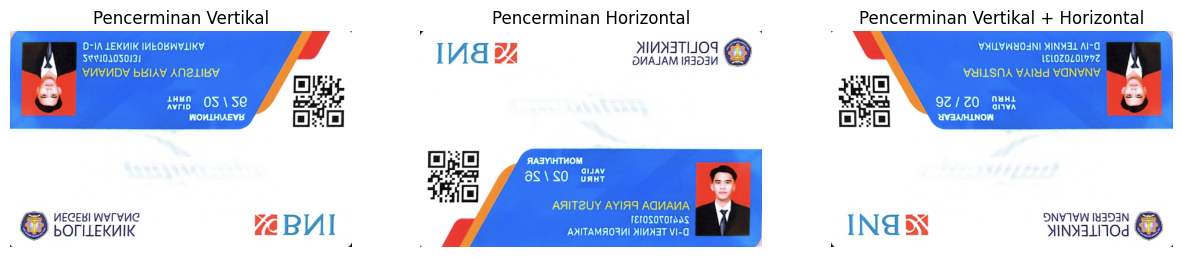

In [32]:
# Flip vertikal
flip_vertical = cv2.flip(image_rgb, 0)

# Flip horizontal
flip_horizontal = cv2.flip(image_rgb, 1)

# Flip vertikal + horizontal
flip_both = cv2.flip(image_rgb, -1)

# Tampilkan
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(flip_vertical)
plt.title("Pencerminan Vertikal")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(flip_horizontal)
plt.title("Pencerminan Horizontal")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(flip_both)
plt.title("Pencerminan Vertikal + Horizontal")
plt.axis("off")

plt.show()

### 3. Rectangle, Circle, dan Teks

Pada citra aktivitas pribadi, dibuat sebuah rectangle dan circle pada bagian wajah/badan. Rectangle dan circle dibuat menggunakan fungsi OpenCV `cv2.rectangle()` dan `cv2.circle()`. Selain itu, ditambahkan teks berupa nama menggunakan `cv2.putText()` dengan pilihan font, ukuran, warna, dan ketebalan yang ditentukan.

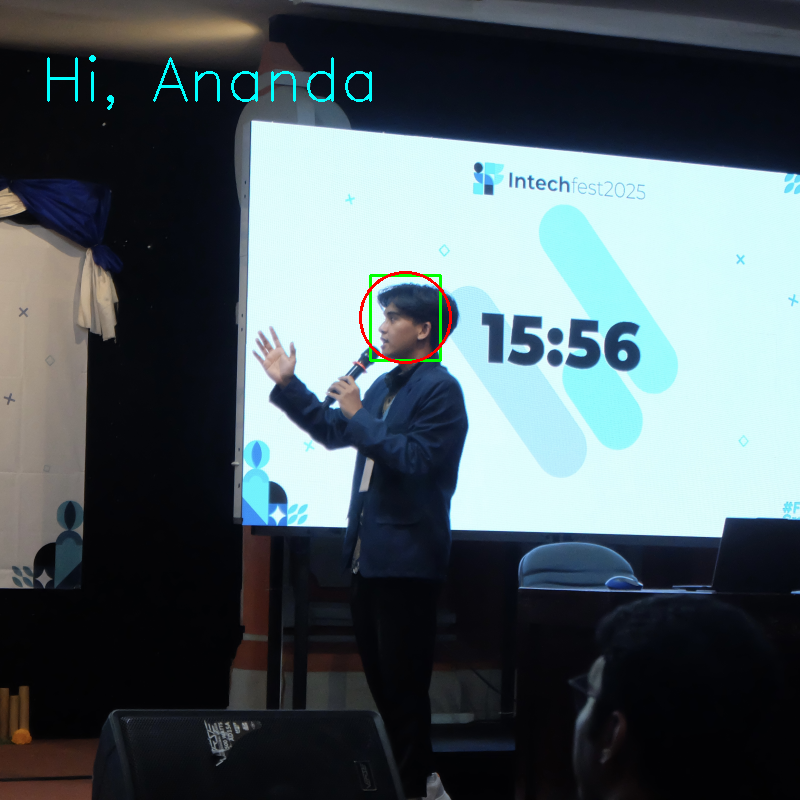

In [38]:
# Baca gambar dan resize ke ukuran fixed (800x800)

img_activity = cv2.imread('/content/drive/MyDrive/Polinema/Semester 5/PCVK/Pertemuan 1/DSCF9661.jpg')
fixed_width, fixed_height = 800, 800
img_activity_resized = cv2.resize(
    img_activity, (fixed_width, fixed_height), interpolation=cv2.INTER_AREA
)

# Koordinat bounding box area wajah pada gambar 800x800
# (x1, y1) = sudut kiri atas wajah, (x2, y2) = sudut kanan bawah wajah
x1, y1 = 370, 275
x2, y2 = 440, 360

# Hitung titik pusat dan radius lingkaran wajah
center_x = (x1 + x2) // 2
center_y = (y1 + y2) // 2
radius = 45

# Buat rectangle (hijau) dan circle (merah)
cv2.rectangle(img_activity_resized, (x1, y1), (x2, y2), (0, 255, 0), 2)
cv2.circle(img_activity_resized, (center_x, center_y), radius, (0, 0, 255), 2)

# Tambahkan Text
cv2.putText(img_activity_resized, "Hi, Ananda", (40, 100), cv2.FONT_HERSHEY_SIMPLEX,fontScale=2, color=(255, 255, 0), thickness=2)

# Tampilkan hasil akhir
cv2_imshow(img_activity_resized)

# Tugas Praktikum - Analisa

### Pertanyaan

Apakah jumlah piksel pada citra tetap sama setelah citra dicerminkan secara horizontal?

Program membaca sebuah citra menggunakan OpenCV, kemudian menghitung jumlah piksel berdasarkan nilai `height × width`. Setelah itu citra dicerminkan secara horizontal menggunakan `cv2.flip()`. Jumlah piksel citra asli dan citra hasil pencerminan kemudian dibandingkan.

In [39]:
# Pencerminan horizontal
image_flip = cv2.flip(image, 1)

# Jumlah pixel
height, width = image.shape[:2]
height_flip, width_flip = image_flip.shape[:2]

jumlah_pixel_asli = height * width
jumlah_pixel_flip = height_flip * width_flip

print("Shape citra asli :", image.shape)
print("Shape citra flip :", image_flip.shape)

print("Jumlah pixel asli :", jumlah_pixel_asli)
print("Jumlah pixel flip :", jumlah_pixel_flip)

print("Apakah jumlah pixel sama?", jumlah_pixel_asli == jumlah_pixel_flip)

Shape citra asli : (1078, 1710, 3)
Shape citra flip : (1078, 1710, 3)
Jumlah pixel asli : 1843380
Jumlah pixel flip : 1843380
Apakah jumlah pixel sama? True



Berdasarkan hasil program, shape citra sebelum dan sesudah pencerminan horizontal adalah (1078, 1710, 3). Jumlah piksel pada citra asli adalah 1843380 dan setelah pencerminan adalah 1843380. Program menghasilkan nilai `True` pada perbandingan jumlah piksel.

Pencerminan horizontal tidak mengubah jumlah piksel pada citra. Operasi tersebut hanya mengubah posisi piksel dari kiri ke kanan, sedangkan ukuran dan jumlah piksel citra tetap sama.

# Tugas Praktikum - Aplikasi

Studi Kasus 1: Panitia sebuah kegiatan perlu membubuhkan label identitas pada ratusan foto dokumentasi. Foto berasal dari beberapa kamera dan ponsel, sehingga ukurannya bermacam-macam. Label harus terlihat seimbang pada semua foto tanpa disetel satu per satu. Fungsi yang sama dikenakan pada dua citra berbeda ukuran. Tinggi bar dan ukuran huruf ikut menyesuaikan, sehingga proporsinya tetap sama.

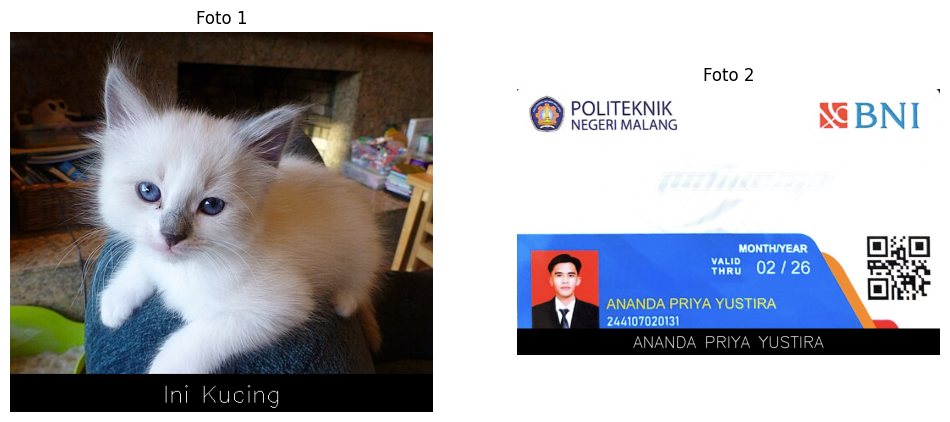

In [56]:
def tambah_label(image, nama):
    height, width = image.shape[:2]

    # Tinggi bar = 10% dari tinggi gambar
    bar_height = int(height * 0.10)

    # Buat bar dengan mengambil bagian bawah gambar
    image_label = image.copy()

    # Bar identitas
    cv2.rectangle(
        image_label,
        (0, height - bar_height),
        (width, height),
        (0, 0, 0),
        -1
    )

    # Ukuran font menyesuaikan tinggi bar
    font_scale = bar_height / 50

    # Ketebalan menyesuaikan ukuran gambar
    thickness = max(1, int(height / 500))

    # Ukuran teks
    text_size = cv2.getTextSize(
        nama,
        cv2.FONT_HERSHEY_SIMPLEX,
        font_scale,
        thickness
    )[0]

    text_width, text_height = text_size

    # Posisi teks di tengah bar
    x = (width - text_width) // 2
    y = height - (bar_height - text_height) // 2

    cv2.putText(
        image_label,
        nama,
        (x, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        font_scale,
        (255, 255, 255),
        thickness
    )

    return image_label


image_1 = cv2.imread("/content/drive/MyDrive/Polinema/Semester 5/PCVK/Pertemuan 1/Juvenile_Ragdoll.jpg")
image_2 = cv2.imread("/content/drive/MyDrive/Polinema/Semester 5/PCVK/Pertemuan 1/KTM_NANDA.png")


hasil_1 = tambah_label(image_1, "Ini Kucing")
hasil_2 = tambah_label(image_2, "ANANDA PRIYA YUSTIRA")

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(hasil_1, cv2.COLOR_BGR2RGB))
plt.title("Foto 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(hasil_2, cv2.COLOR_BGR2RGB))
plt.title("Foto 2")
plt.axis("off")

plt.show()

Studi Kasus 2: Marketplace seperti Tokopedia dan Shopee menampilkan foto produk dalam bingkai persegi 1:1. Foto penjual yang berukuran potrait atau lanskap akan terpotong atau terlihat tidak proporsional bila diunggah begitu saja. Bangun program yang mengubah foto berukuran apa pun menjadi thumbnail persegi tanpa mengubah rasio aslinya, dengan sisa ruang diisi kanvas berwarna. Dalam hal ini, rasio asli tetap terjaga, citra terpasang tepat di tengah kanvas, tambahkan logo nama toko berukuran proporsional pada gambar.


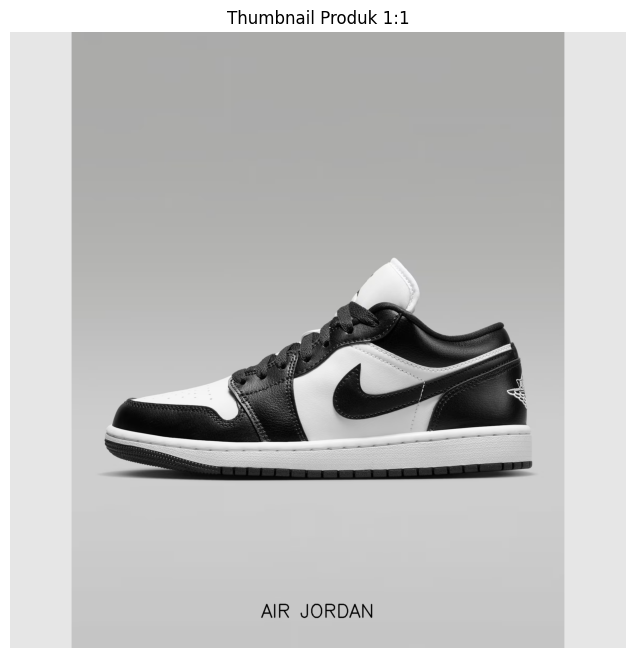

In [59]:
def buat_thumbnail(image, nama_toko):

    height, width = image.shape[:2]

    # Sisi canvas persegi mengikuti sisi terbesar gambar
    canvas_size = max(height, width)

    # Buat canvas berwarna
    canvas = np.zeros(
        (canvas_size, canvas_size, 3),
        dtype=image.dtype
    )

    # Beri warna pada canvas
    canvas[:] = (230, 230, 230)

    # Tentukan ukuran baru agar rasio gambar tetap
    scale = canvas_size / max(height, width)

    new_width = int(width * scale)
    new_height = int(height * scale)

    resized = cv2.resize(
        image,
        (new_width, new_height)
    )

    # Posisi agar gambar berada tepat di tengah
    x = (canvas_size - new_width) // 2
    y = (canvas_size - new_height) // 2

    # Tempel gambar ke canvas
    canvas[
        y:y + new_height,
        x:x + new_width
    ] = resized

    # Logo / nama toko

    # Ukuran font berdasarkan canvas
    font_scale = canvas_size / 1000

    thickness = max(
        1,
        int(canvas_size / 500)
    )

    text_size = cv2.getTextSize(
        nama_toko,
        cv2.FONT_HERSHEY_SIMPLEX,
        font_scale,
        thickness
    )[0]

    text_width, text_height = text_size

    # Posisi nama toko di bagian bawah dan tengah
    text_x = (canvas_size - text_width) // 2
    text_y = canvas_size - int(canvas_size * 0.05)

    cv2.putText(
        canvas,
        nama_toko,
        (text_x, text_y),
        cv2.FONT_HERSHEY_SIMPLEX,
        font_scale,
        (0, 0, 0),
        thickness
    )

    return canvas

image_produk_1 = cv2.imread('/content/drive/MyDrive/Polinema/Semester 5/PCVK/Pertemuan 2/AIR JORDAN.avif')

thumbnail = buat_thumbnail(image_produk_1, "AIR JORDAN")
plt.figure(figsize=(8, 8))

plt.imshow(
    cv2.cvtColor(thumbnail, cv2.COLOR_BGR2RGB)
)

plt.title("Thumbnail Produk 1:1")
plt.axis("off")
plt.show()